In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
datapath = '../data/data_cats_and_dogs'

In [18]:
size = (64, 64)  # taille des images redimensionnées
batch_size = 16

transform = transforms.Compose([transforms.Resize(size),
                                transforms.ToTensor()])
                                #transforms.Normalize([0, 0, 0], [1, 1, 1])])

def mask_transform(mask):
    mask = mask.resize(size, Image.NEAREST)
    mask_np = np.array(mask)
    # Si les valeurs sont dans [0, 1], on les remet sur 0, 1, 2
    uniques = np.unique(mask_np)
    # Mappe les valeurs uniques à 0, 1, 2
    mask_int = np.searchsorted(uniques, mask_np)
    return torch.from_numpy(mask_int).long()

target_transform = mask_transform

target_types = 'segmentation'

train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform,
test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
img, masks = train_dataset[0]
print(f'Image batch shape: {img.size()}')
print(f'Mask batch shape: {masks.size()}')

Image batch shape: torch.Size([3, 64, 64])
Mask batch shape: torch.Size([64, 64])


Epoch 1/20
train Loss: 0.8075
val Loss: 0.6968
Epoch 2/20
train Loss: 0.6544
val Loss: 0.6345
Epoch 3/20
train Loss: 0.5858
val Loss: 0.5462
Epoch 4/20
train Loss: 0.5332
val Loss: 0.4992
Epoch 5/20
train Loss: 0.4930
val Loss: 0.4856
Epoch 6/20
train Loss: 0.4737
val Loss: 0.4695
Epoch 7/20
train Loss: 0.4448
val Loss: 0.4386
Epoch 8/20
train Loss: 0.4382
val Loss: 0.4606
Epoch 9/20
train Loss: 0.4134
val Loss: 0.4524
Epoch 10/20
train Loss: 0.3979
val Loss: 0.4265
Epoch 11/20
train Loss: 0.3893
val Loss: 0.4190
Epoch 12/20
train Loss: 0.3732
val Loss: 0.4118
Epoch 13/20
train Loss: 0.3576
val Loss: 0.4133
Epoch 14/20
train Loss: 0.3480
val Loss: 0.3993
Epoch 15/20
train Loss: 0.3386
val Loss: 0.4183
Epoch 16/20
train Loss: 0.3263
val Loss: 0.4039
Epoch 17/20
train Loss: 0.3162
val Loss: 0.3876
Epoch 18/20
train Loss: 0.3032
val Loss: 0.4056
Epoch 19/20
train Loss: 0.2915
val Loss: 0.4083
Epoch 20/20
train Loss: 0.2815
val Loss: 0.4003


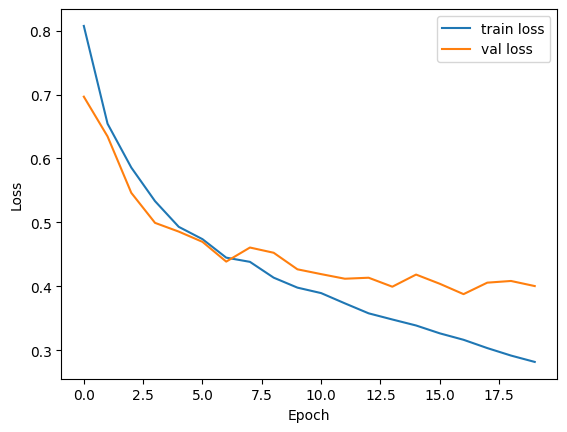

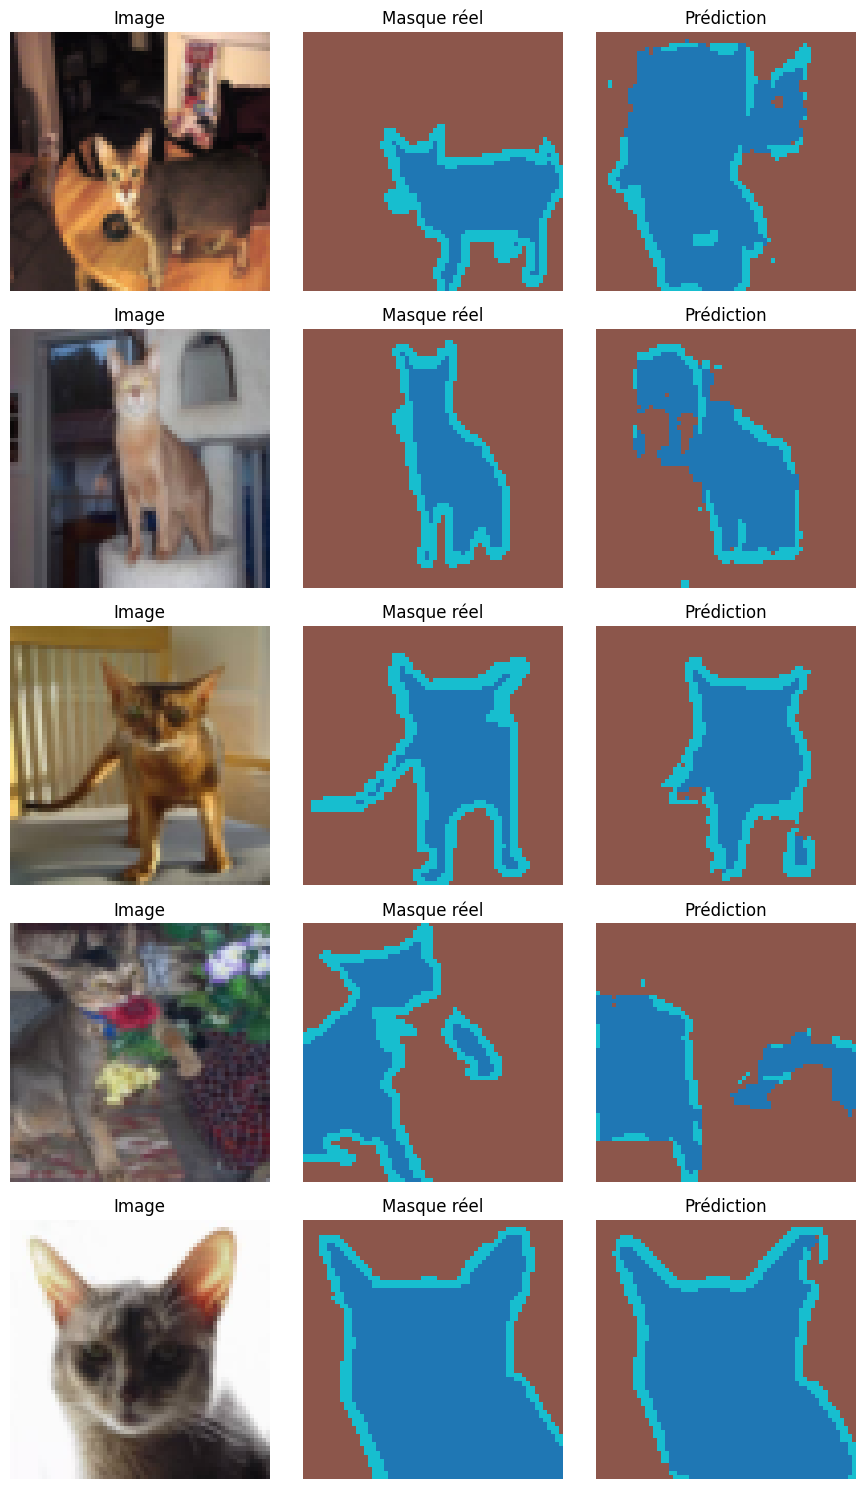

In [21]:
# -----------------------------
# 1. Définition d'un U-Net léger
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNetSmall(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.down1 = double_conv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = double_conv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = double_conv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = double_conv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = double_conv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = double_conv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = double_conv(64, 32)

        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        u3 = self.up3(bn)
        c3 = self.conv3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.conv2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.conv1(torch.cat([u1, d1], dim=1))

        out = self.out(c1)
        return out

# ------------------------------------------
# 2. Fonction d'entraînement avec suivi des pertes
# ------------------------------------------
def train_unet(model, dataloaders, dataset_sizes, optimizer, criterion, num_epochs=10, device='cuda'):
    model.to(device)
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            with torch.set_grad_enabled(phase == 'train'):
                for imgs, masks in dataloaders[phase]:
                    imgs = imgs.to(device)
                    masks = masks.to(device)
                    if masks.ndim == 4 and masks.shape[1] == 1:
                        masks = masks.squeeze(1)
                    if phase == 'train':
                        optimizer.zero_grad()
                    outputs = model(imgs)
                    loss = criterion(outputs, masks.long())
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item() * imgs.size(0)
            epoch_loss = running_loss / dataset_sizes[phase]
            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)
            print(f"{phase} Loss: {epoch_loss:.4f}")
    # Plot des pertes
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    path = 'unet_small_model.pth'
    torch.save(model.state_dict(), path)
    return model, train_losses, val_losses

# ---------------------------------------------------
# 3. Visualisation entrée / label / prédiction
# ---------------------------------------------------
def plot_segmentation_results(model, dataset, device='cuda', num_images=5):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))
    for i in range(num_images):
        img, mask = dataset[i]
        img_input = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_input)
            pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu()
        axes[i, 0].imshow(torch.permute(img, (1, 2, 0)))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(mask.squeeze(), cmap="tab10")
        axes[i, 1].set_title("Masque réel")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_mask, cmap="tab10")
        axes[i, 2].set_title("Prédiction")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# 4. Exemple d'utilisation
# ---------------------------------------------------
dataloaders = {
    'train': train_loader,
    'val': test_loader
}
dataset_sizes = {
    'train': len(train_dataset),
    'val': len(test_dataset)
}
# Initialisation du modèle, optimizer et loss
num_classes = 3  # fond, contour, animal
model = UNetSmall(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 20

# Entraînement du modèle
model, train_losses, val_losses = train_unet(
    model,
    dataloaders,
    dataset_sizes,
    optimizer,
    criterion,
    num_epochs=num_epochs,
    device=device
 )

# Visualisation sur l'ensemble de validation
plot_segmentation_results(model, dataloaders['val'].dataset, device=device, num_images=5)